# 연령별취업자수관계
- https://kosis.kr/search/search.do
- 행정구역(시도)/성/연령별 취업자 검색

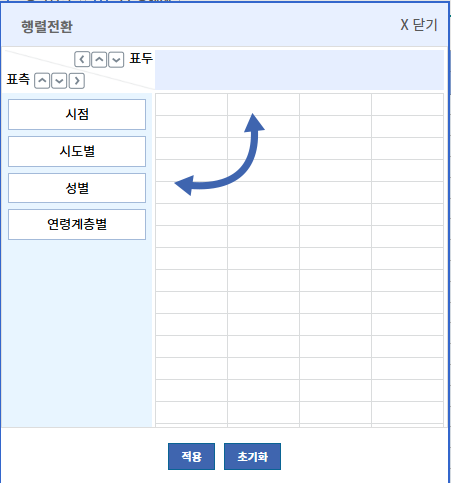

In [3]:
import pandas as pd
file_path = './dataset/행정구역시도성연령별취업자202606.csv'
raw = pd.read_csv(file_path, encoding="EUC-KR")
raw.head()

,시점,시도별,성별,연령계층별,데이터
0,2015.1/4,서울특별시,남자,20 - 29세,322
1,2015.1/4,서울특별시,남자,30 - 39세,752
2,2015.1/4,서울특별시,남자,40 - 49세,750
3,2015.1/4,서울특별시,남자,50 - 59세,669
4,2015.1/4,서울특별시,남자,60세이상,366


In [12]:
df['location'].unique

<bound method Series.unique of 0       서울특별시
1       서울특별시
2       서울특별시
3       서울특별시
4       서울특별시
        ...  
7645      제주도
7646      제주도
7647      제주도
7648      제주도
7649      제주도
Name: location, Length: 7650, dtype: object>

In [5]:
df = raw.copy()
df.columns = ['date','location','gender','age','value']
df['date'] = df['date'].str.replace('.', '/', regex=False)
df.loc[df['location'] == '세종특별자치시','value'] = (df.loc[df['location'] == '세종특별자치시','value'].replace('-', '0'))
df['value'] = df['value'].astype(int)
gdata = df.groupby('date')['value'].sum().reset_index(name="total")
gdata

,date,total
0,2015/1/4,25295
1,2015/2/4,26114
2,2015/3/4,26214
3,2015/4/4,26148
4,2016/1/4,25502
5,2016/2/4,26320
6,2016/3/4,26467
7,2016/4/4,26394
8,2017/1/4,25846
9,2017/2/4,26665


Text(0.2, 0.4, '한글')

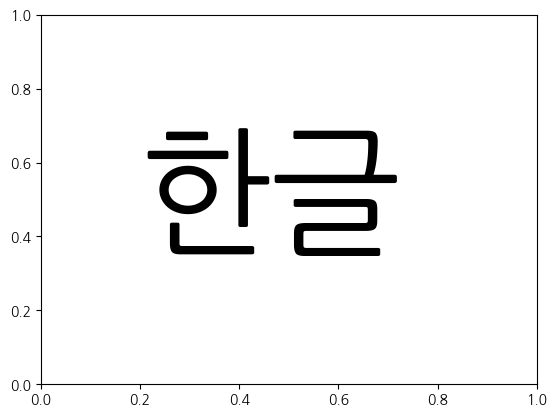

In [6]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [7]:
# raw['location'].unique()

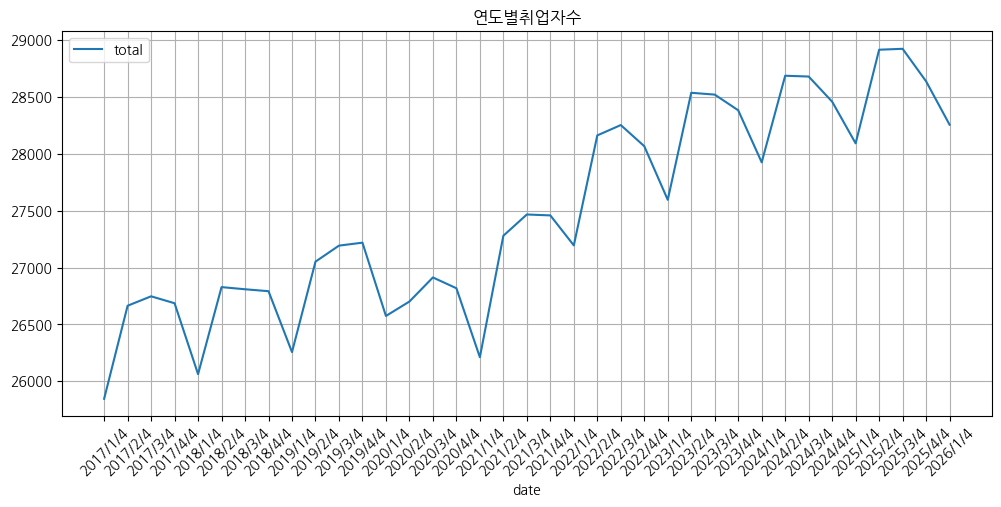

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = raw.copy()
df.columns = ['date', 'location', 'gender', 'age', 'value']
df['date'] = df['date'].str.replace('.', '/', regex=False)
# 방법1
# df.iloc[1360:,:]
# 방법2
gdata = df.loc[df['date'] >= "2017.1/4"].copy()

gdata['value'] = gdata['value'].astype('int')

result = gdata.groupby('date')['value'].sum().reset_index(name='total')
result.plot('date',figsize=(12,5),title="연도별취업자수")

plt.xticks(range(len(result['date'])), rotation=45, labels=result['date'])
plt.grid()
plt.show()

In [15]:
# 남녀를 구분하여 차트를 2중으로 겹쳐라.
gdata

,date,location,gender,age,value
1360,2017/1/4,서울특별시,남자,20 - 29세,320
1361,2017/1/4,서울특별시,남자,30 - 39세,714
1362,2017/1/4,서울특별시,남자,40 - 49세,734
1363,2017/1/4,서울특별시,남자,50 - 59세,658
1364,2017/1/4,서울특별시,남자,60세이상,394
...,...,...,...,...,...
7645,2026/1/4,제주도,여자,20 - 29세,20
7646,2026/1/4,제주도,여자,30 - 39세,29
7647,2026/1/4,제주도,여자,40 - 49세,41
7648,2026/1/4,제주도,여자,50 - 59세,48


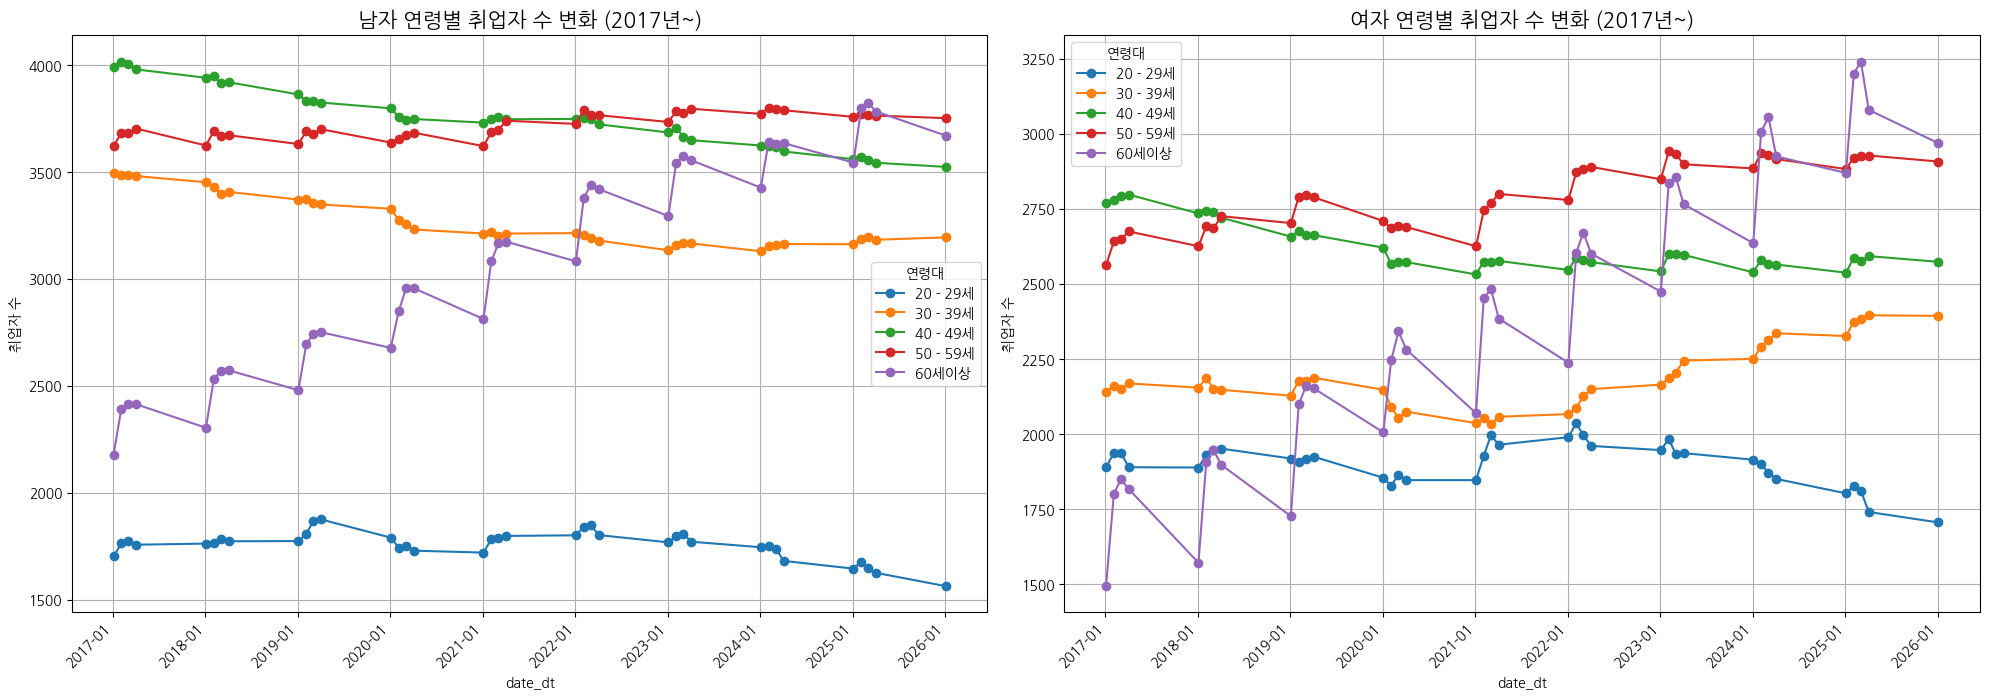

In [19]:
# 문제 : 2017년 1/4분기 부터 2026년 1/4까지 연령별 남, 녀 취업자수 통계 각각 시각화하기

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 폰트 설정
plt.rc('font', family='NanumGothic')

# 1. 전처리 안전하게 수행 (이미 datetime이면 건너뜀)
if df['date'].dtype == 'object':
    df['date_dt'] = pd.to_datetime(df['date'].str.replace('/', '-'))
else:
    df['date_dt'] = pd.to_datetime(df['date'])

# 2. 'value' 컬럼을 숫자형으로 변환
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# 이후 코드는 동일합니다
filtered_df = df[df['date_dt'] >= "2017-01-01"].copy()

# 연령대별, 성별별 데이터 그룹화
genders = ['남자', '여자']
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for i, gender in enumerate(genders):
    gender_data = filtered_df[filtered_df['gender'] == gender]
    
    # 연령대별로 피벗 테이블 생성
    pivot_df = gender_data.pivot_table(index='date_dt', columns='age', values='value', aggfunc='sum')
    
    # 3. 데이터가 비어있지 않은지 확인 후 그래프 그리기
    if not pivot_df.empty:
        pivot_df.plot(ax=axes[i], marker='o')
        axes[i].set_title(f'{gender} 연령별 취업자 수 변화 (2017년~)', fontsize=15)
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        axes[i].set_ylabel('취업자 수')
        axes[i].grid(True)
        axes[i].legend(title='연령대')

plt.tight_layout()
for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.show()